In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/processed_data.csv")
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Total_Delay,Delayed_Flight,Average_Service_Rating,Long_Haul
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,4,5,5,25,18.0,0,43.0,1,3.846154,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,4,1,1,6.0,0,7.0,0,2.307692,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,4,4,5,0,0.0,1,0.0,0,3.846154,0
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,1,4,2,11,9.0,0,20.0,1,2.846154,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,3,0,0.0,1,0.0,0,3.538462,0


In [4]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

for column in categorical_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  int64  
 1   Customer Type                      103904 non-null  int64  
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  int64  
 4   Class                              103904 non-null  int64  
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    103904 non-null

In [6]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (103904, 26)
y shape: (103904,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (83123, 26)
Test Shape: (20781, 26)


**Some algorithms need scaling:**
* Logistic Regression
* KNN
* SVM

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline Model Training

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [11]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

In [12]:
results = []

In [13]:
for name, model in models.items():

    # Models requiring scaled data
    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, precision, recall, f1, roc_auc
    ])

In [14]:
baseline_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])
baseline_results.sort_values(by="F1 Score", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest,0.962418,0.967804,0.944697,0.956111,0.993932
6,SVM,0.952457,0.953604,0.935813,0.944625,0.988692
2,Decision Tree,0.943939,0.929636,0.941921,0.935738,0.943702
4,Gradient Boosting,0.942255,0.943013,0.922488,0.932637,0.988210
1,KNN,0.924210,0.941526,0.879733,0.909581,0.968400
5,AdaBoost,0.909485,0.905602,0.883176,0.894249,0.971216
0,Logistic Regression,0.876714,0.870075,0.841088,0.855336,0.928916


## Hyperparameter Tuning

**Logistic Regression**

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10]
}

tuned_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [16]:
tuned_lr.fit(X_train_scaled, y_train)
print("Best Params:", tuned_lr.best_params_)
print("Best Score:", tuned_lr.best_score_)


Best Params: {'C': 10}
Best Score: 0.8528760764189801


In [17]:
lr_pred = tuned_lr.predict(X_test_scaled)
print("Tuned Logistic Regression F1 Score", f1_score(y_test, lr_pred))

Tuned Logistic Regression F1 Score 0.8553359683794466


**K Nearest Neighbor**

In [18]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
}

tuned_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [19]:
tuned_knn.fit(X_train_scaled, y_train)
print("Best Params:", tuned_knn.best_params_)
print("Best Score:", tuned_knn.best_score_)

Best Params: {'n_neighbors': 7}
Best Score: 0.9067283980640443


In [20]:
knn_pred = tuned_knn.predict(X_test_scaled)
print("Tuned KNN F1 Score:", f1_score(y_test, knn_pred))

Tuned KNN F1 Score: 0.9095407987110139


**Support Vector Machine**

In [21]:
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.1, 1, 10]
}

tuned_svm = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [22]:
tuned_svm.fit(X_train_scaled, y_train)
print("Best Params:", tuned_svm.best_params_)
print("Best Score:", tuned_svm.best_score_)

Best Params: {'C': 0.1}
Best Score: 0.8516995277840227


In [23]:
svm_pred = tuned_svm.predict(X_test_scaled)
print("Tuned Linear SVC F1 Score:", f1_score(y_test, svm_pred))

Tuned Linear SVC F1 Score: 0.8564485136204363


**Decision Tree**

In [24]:
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

tuned_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [25]:
tuned_dt.fit(X_train, y_train)
print("Best Params:", tuned_dt.best_params_)
print("Best Score:", tuned_dt.best_score_)

Best Params: {'max_depth': 15, 'min_samples_split': 10}
Best Score: 0.9410263766209144


In [26]:
dt_pred = tuned_dt.predict(X_test)
print("Decision Tree F1 Score:", f1_score(y_test, dt_pred))

Decision Tree F1 Score: 0.9445378151260504


**Random Forest**

In [27]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

tuned_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [28]:
tuned_rf.fit(X_train, y_train)
print("Best Params:", tuned_rf.best_params_)
print("Best Score", tuned_rf.best_score_)

Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Score 0.9534315472149942


In [29]:
rf_pred = tuned_rf.predict(X_test)
print("Random Forest F1 Score:", f1_score(y_test, rf_pred))

Random Forest F1 Score: 0.9556567189344124


**Gradient Boosting**

In [30]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

tuned_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)


In [31]:
tuned_gb.fit(X_train, y_train)
print("Best Params:", tuned_gb.best_params_)
print("Best Score:", tuned_gb.best_score_)

Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best Score: 0.9540569963282168


In [32]:
gb_pred = tuned_gb.predict(X_test)
print("Gradient boosting F1 Score:", f1_score(y_test, gb_pred))

Gradient boosting F1 Score: 0.9574898785425101


**AdaBoost**

In [33]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

tuned_ab = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [34]:
tuned_ab.fit(X_train, y_train)
print("Best Params:", tuned_ab.best_params_)
print("Best Score:", tuned_ab.best_score_)

Best Params: {'learning_rate': 1.0, 'n_estimators': 200}
Best Score: 0.9143698348526326


In [35]:
ab_pred = tuned_ab.predict(X_test)
print("Adaboost F1 Score:", f1_score(y_test, ab_pred))

Adaboost F1 Score: 0.9147787364319511


**Final comparison of tuned models**

In [36]:
tuned_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'AdaBoost'
    ],
    'F1 Score': [
        f1_score(y_test, tuned_lr.predict(X_test_scaled)),
        f1_score(y_test, tuned_knn.predict(X_test_scaled)),
        f1_score(y_test, tuned_svm.predict(X_test_scaled)),
        f1_score(y_test, tuned_dt.predict(X_test)),
        f1_score(y_test, tuned_rf.predict(X_test)),
        f1_score(y_test, tuned_gb.predict(X_test)),
        f1_score(y_test, tuned_ab.predict(X_test))
    ]
})

tuned_results.sort_values(by='F1 Score', ascending=False)


,Model,F1 Score
5,Gradient Boosting,0.957490
4,Random Forest,0.955657
3,Decision Tree,0.944538
6,AdaBoost,0.914779
1,KNN,0.909541
2,SVM,0.856449
0,Logistic Regression,0.855336


In [37]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = tuned_gb.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11511   265]
 [  491  8514]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.95      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



In [38]:
from sklearn.metrics import roc_auc_score

y_prob = tuned_gb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9949342709288921


In [39]:
import joblib
joblib.dump(tuned_gb, "../model/passenger_satisfaction_model.pkl")

['../model/passenger_satisfaction_model.pkl']

After preprocessing the dataset and training multiple machine learning models, hyperparameter optimization was performed using GridSearchCV. The evaluated models included Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest, Gradient Boosting, and AdaBoost. Among all models, Gradient Boosting achieved the best performance with an F1 Score of 0.9575 and an accuracy of 96.36%. The model also obtained a ROC-AUC score of 0.9949, demonstrating excellent class-separation capability. Based on these evaluation metrics, Gradient Boosting was selected as the final model for prediction and deployment.

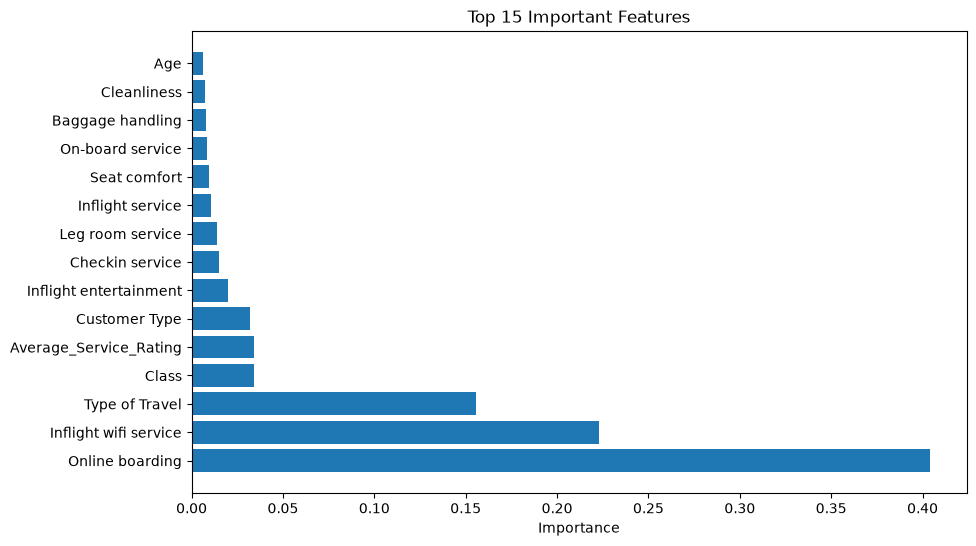

In [40]:
import matplotlib.pyplot as plt
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tuned_gb.best_estimator_.feature_importances_
})

importance = importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'][:15], importance['Importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Important Features')
plt.show()